In [7]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from script import load_experiment
from script_nonconvex import load_experiment as load_experiment_nonconvex

In [2]:
path_load = 'results/experiment-2026-01-07_11-20-49.json'
data = load_experiment(path_load)
n, m, random_seed, nb_rounds, d_star, alpha_bar_dual_sub_list, alpha_bar_two_stage_list, history_dual_sub_list, history_stoch_dual_sub_list, history_block_FW_list = data
n, m, nb_rounds

(10000, 24, 5)

In [3]:
#Get the best dual value found over all algorithms
best_dual_value = - np.inf
for (i, alpha) in enumerate(alpha_bar_dual_sub_list):
    candidate_value = np.max(history_dual_sub_list[i]['dual_value'])
    argmax = np.argmax(history_dual_sub_list[i]['dual_value'])
    print(i, alpha, candidate_value, argmax, len(history_dual_sub_list[i]['dual_value']))
    best_dual_value = candidate_value if candidate_value > best_dual_value else best_dual_value
for (i, alpha) in enumerate(alpha_bar_two_stage_list):
    for seed_round in range(nb_rounds):
        candidate_value = np.max(history_stoch_dual_sub_list[i][str(seed_round)]['dual_value'])
        argmax = np.argmax(history_stoch_dual_sub_list[i][str(seed_round)]['dual_value'])
        print(i, alpha, seed_round, candidate_value, argmax)
        best_dual_value = candidate_value if candidate_value > best_dual_value else best_dual_value
print(best_dual_value, d_star)
best_dual_value = d_star if d_star > best_dual_value else best_dual_value
print(best_dual_value)

0 10 438.3896741603362 99 100
0 10 0 438.53621887265297 99
0 10 1 438.5362236404442 99
0 10 2 438.5362245607268 99
0 10 3 438.5362113044508 99
0 10 4 438.5362223108216 99
438.5362245607268 438.53704869531776
438.53704869531776


In [4]:
color_dual_sub = 'red'
color_stoch_dual_sub = 'blue'
colors_block_fw = 'green'

linestyles = ['-', '--', ':', '-.', (0, (1, 5))]

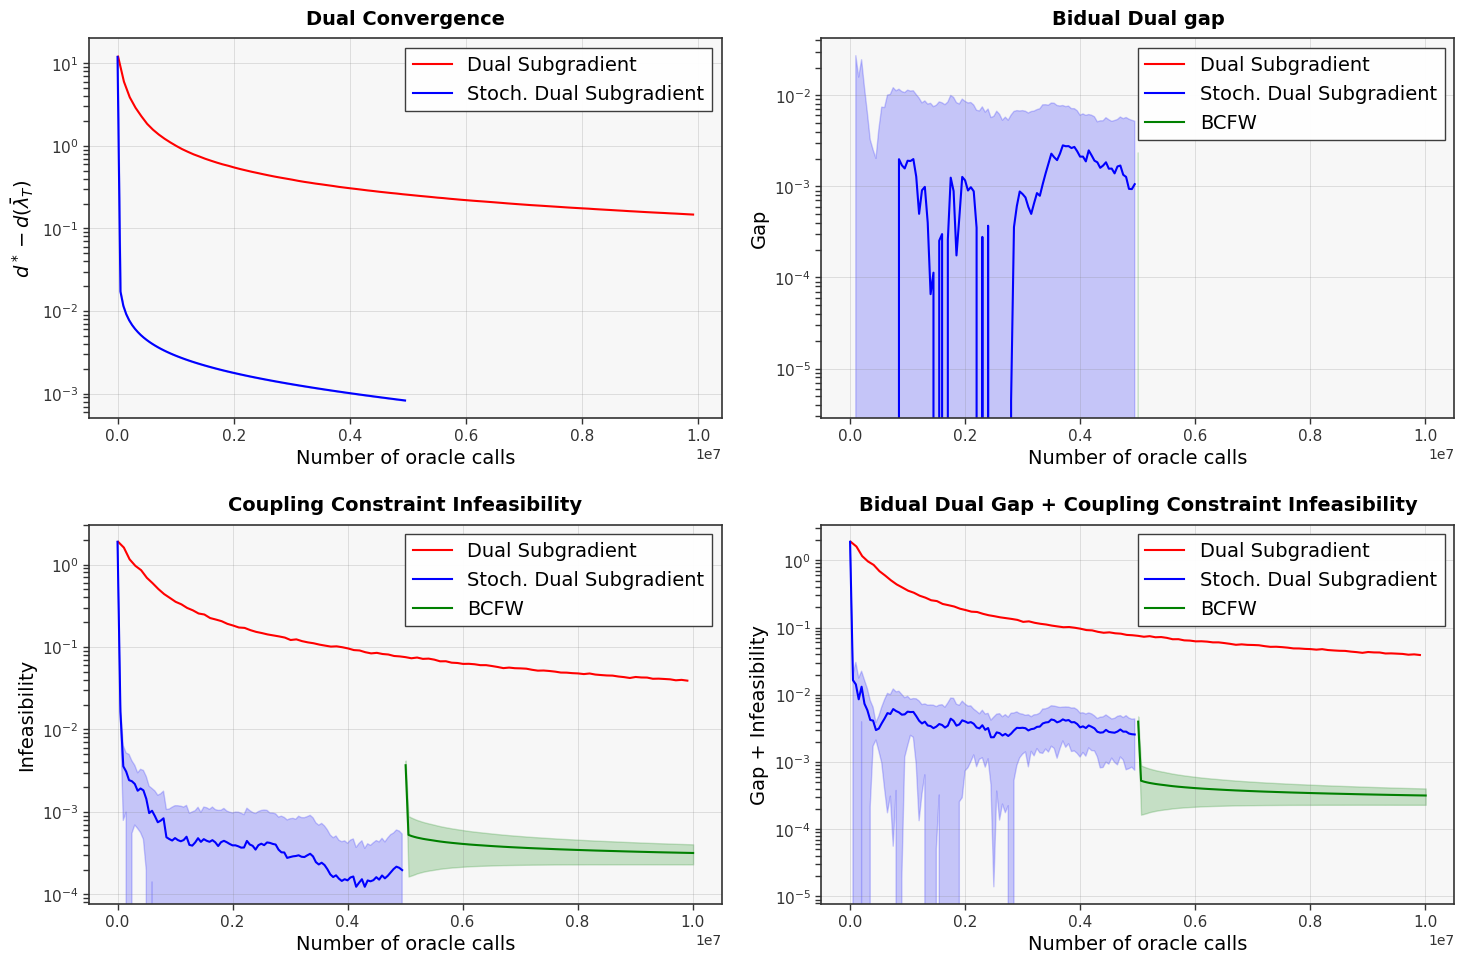

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))


# Apply style improvements to all subplots
for ax in [ax1, ax2, ax3, ax4]:
    # Light gray background
    ax.set_facecolor('#f7f7f7')
    
    # Grid lines (light gray, behind plot elements)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.3)
    #ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.3)
    
    # Set grid behind plot elements
    #ax.set_axisbelow(True)
    
    # Thicker axis spines with darker color
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('#333333')
    
    # Improve tick parameters
    ax.tick_params(which='both', direction='out', length=4, width=1, 
                   colors='#333333', labelsize=11)

#remove some alpha for clarity
alpha_bar_dual_sub_list_to_plot = [10]
alpha_bar_two_stage_list_to_plot = [10]

#create sublinear curves
sublinear_curve_half = np.array([1/np.sqrt(g) for g in history_stoch_dual_sub_list[0]['0']['nb_oracle_calls']])

for (i, alpha) in enumerate(alpha_bar_dual_sub_list):
    if alpha in alpha_bar_dual_sub_list_to_plot:
        #ax1.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls']), best_dual_value - np.array(history_dual_sub_list[i]['dual_value']), label=f"Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_dual_sub)
        ax1.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls']), best_dual_value - np.array(history_dual_sub_list[i]['dual_value']), label=f"Dual Subgradient", linestyle=linestyles[i], color=color_dual_sub)
for (i, alpha) in enumerate(alpha_bar_two_stage_list):
    if alpha in alpha_bar_two_stage_list_to_plot:
        for seed_round in range(nb_rounds):
            #average over rounds
            if seed_round == 0:
                dual_values = np.array(history_stoch_dual_sub_list[i][str(seed_round)]['dual_value'])
            else:
                dual_values += np.array(history_stoch_dual_sub_list[i][str(seed_round)]['dual_value'])
        dual_values /= nb_rounds
        nb_oracle_calls = np.array(history_stoch_dual_sub_list[i][str(0)]['nb_oracle_calls'])
        #ax1.plot(nb_oracle_calls, best_dual_value - dual_values, label=f"Stoch. Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_stoch_dual_sub)
        ax1.plot(nb_oracle_calls, best_dual_value - dual_values, label=f"Stoch. Dual Subgradient", linestyle=linestyles[i], color=color_stoch_dual_sub)
        #plot standard deviation as shaded area
        std_dev = np.zeros_like(dual_values)
        for seed_round in range(nb_rounds):
            std_dev += (np.array(history_stoch_dual_sub_list[i][str(seed_round)]['dual_value']) - dual_values)**2
        std_dev = np.sqrt(std_dev / nb_rounds)
        ax1.fill_between(nb_oracle_calls, best_dual_value - dual_values - std_dev, best_dual_value - dual_values + std_dev, color=color_stoch_dual_sub, alpha=0.2)    

ax1.legend()
ax1.set_xlabel('Number of oracle calls')
ax1.set_ylabel(r'$d^* - d(\bar{\lambda}_T)$')
ax1.set_title('Dual Convergence')
ax1.set_yscale('log')


first_index = 0
for (i, alpha) in enumerate(alpha_bar_dual_sub_list):
    if alpha in alpha_bar_dual_sub_list_to_plot:
        #ax2.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls'])[first_index:], np.array(history_dual_sub_list[i]['primal_value'][first_index:]) - best_dual_value, label=f"Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_dual_sub)
        ax2.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls'])[first_index:], np.array(history_dual_sub_list[i]['primal_value'][first_index:]) - best_dual_value, label=f"Dual Subgradient", linestyle=linestyles[i], color=color_dual_sub)
for (i, alpha) in enumerate(alpha_bar_two_stage_list):
    if alpha in alpha_bar_two_stage_list_to_plot:
        #ax2.plot(np.array(history_stoch_dual_sub_list[i]['nb_oracle_calls'])[first_index:]/n, history_stoch_dual_sub_list[i]['primal_value'][first_index:] - best_dual_value, label=f"Stoch. Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_stoch_dual_sub)
        #ax2.plot(np.array(history_block_FW_list[i]['nb_oracle_calls'])/n, history_block_FW_list[i]['primal_value'] - best_dual_value, label=f"BCFW - {alpha}", linestyle=linestyles[i], color=colors_block_fw)
        for seed_round in range(nb_rounds):
            #average over rounds
            if seed_round == 0:
                primal_values_stoch_dual_sub = np.array(history_stoch_dual_sub_list[i][str(seed_round)]['primal_value'])
                primal_values_block_FW = np.array(history_block_FW_list[i][str(seed_round)]['primal_value'])
            else:
                primal_values_stoch_dual_sub += np.array(history_stoch_dual_sub_list[i][str(seed_round)]['primal_value'])
                primal_values_block_FW += np.array(history_block_FW_list[i][str(seed_round)]['primal_value'])
        primal_values_stoch_dual_sub /= nb_rounds
        primal_values_block_FW /= nb_rounds
        nb_oracle_calls_stoch_dual_sub = np.array(history_stoch_dual_sub_list[i][str(0)]['nb_oracle_calls'])
        nb_oracle_calls_block_FW = np.array(history_block_FW_list[i][str(0)]['nb_oracle_calls'])
        #ax2.plot(nb_oracle_calls_stoch_dual_sub, primal_values_stoch_dual_sub - best_dual_value, label=f"Stoch. Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_stoch_dual_sub)
        #ax2.plot(nb_oracle_calls_block_FW, primal_values_block_FW - best_dual_value, label=f"Stoch. Dual Subgradient - {alpha}", linestyle=linestyles[i], color=colors_block_fw)
        ax2.plot(nb_oracle_calls_stoch_dual_sub, primal_values_stoch_dual_sub - best_dual_value, label=f"Stoch. Dual Subgradient", linestyle=linestyles[i], color=color_stoch_dual_sub)
        ax2.plot(nb_oracle_calls_block_FW, primal_values_block_FW - best_dual_value, label=f"BCFW", linestyle=linestyles[i], color=colors_block_fw)
        #plot standard deviation as shaded area
        std_dev_stoch_dual_sub = np.zeros_like(primal_values_stoch_dual_sub)
        std_dev_block_fw = np.zeros_like(primal_values_block_FW)
        for seed_round in range(nb_rounds):
            std_dev_stoch_dual_sub += (np.array(history_stoch_dual_sub_list[i][str(seed_round)]['primal_value']) - primal_values_stoch_dual_sub)**2
            std_dev_block_fw += (np.array(history_block_FW_list[i][str(seed_round)]['primal_value']) - primal_values_block_FW)**2
        std_dev_stoch_dual_sub = np.sqrt(std_dev_stoch_dual_sub / nb_rounds)
        std_dev_block_fw = np.sqrt(std_dev_block_fw / nb_rounds)
        ax2.fill_between(nb_oracle_calls_stoch_dual_sub, primal_values_stoch_dual_sub - best_dual_value - std_dev_stoch_dual_sub, primal_values_stoch_dual_sub - best_dual_value + std_dev_stoch_dual_sub, color=color_stoch_dual_sub, alpha=0.2)
        ax2.fill_between(nb_oracle_calls_block_FW, primal_values_block_FW - best_dual_value - std_dev_block_fw, primal_values_block_FW - best_dual_value + std_dev_block_fw, color=colors_block_fw, alpha=0.2)

ax2.set_xlabel('Number of oracle calls')
ax2.set_ylabel('Gap')
ax2.set_yscale('log')
#ax2.set_xscale('log')
ax2.set_title("Bidual Dual gap")
ax2.legend()


for (i, alpha) in enumerate(alpha_bar_dual_sub_list):
    if alpha in alpha_bar_dual_sub_list_to_plot:
        #ax3.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls']), history_dual_sub_list[i]['infeasibility'], label=f"Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_dual_sub)
        ax3.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls']), history_dual_sub_list[i]['infeasibility'], label=f"Dual Subgradient", linestyle=linestyles[i], color=color_dual_sub)
for (i, alpha) in enumerate(alpha_bar_two_stage_list):
    if alpha in alpha_bar_two_stage_list_to_plot:
        for seed_round in range(nb_rounds):
            #average over rounds
            if seed_round == 0:
                infeasibility_values_stoch_dual_sub = np.array(history_stoch_dual_sub_list[i][str(seed_round)]['infeasibility'])
                infeasibility_values_block_fw = np.array(history_block_FW_list[i][str(seed_round)]['infeasibility'])
                #nb_oracle_calls = np.array(history_stoch_dual_sub_list[i][str(seed_round)]['nb_oracle_calls'])
            else:
                infeasibility_values_stoch_dual_sub += np.array(history_stoch_dual_sub_list[i][str(seed_round)]['infeasibility'])
                infeasibility_values_block_fw += np.array(history_block_FW_list[i][str(seed_round)]['infeasibility'])
                #nb_oracle_calls += np.array(history_stoch_dual_sub_list[i][str(seed_round)]['nb_oracle_calls'])
        infeasibility_values_stoch_dual_sub /= nb_rounds
        infeasibility_values_block_fw /= nb_rounds
        nb_oracle_calls_stoch_dual_sub = np.array(history_stoch_dual_sub_list[i][str(0)]['nb_oracle_calls'])
        nb_oracle_calls_block_FW = np.array(history_block_FW_list[i][str(0)]['nb_oracle_calls'])
        
        #ax3.plot(nb_oracle_calls_stoch_dual_sub, infeasibility_values_stoch_dual_sub, label=f"Stoch. Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_stoch_dual_sub)
        #ax3.plot(nb_oracle_calls_block_FW, infeasibility_values_block_fw, label=f"BCFW - {alpha}", linestyle=linestyles[i], color=colors_block_fw)
        ax3.plot(nb_oracle_calls_stoch_dual_sub, infeasibility_values_stoch_dual_sub, label=f"Stoch. Dual Subgradient", linestyle=linestyles[i], color=color_stoch_dual_sub)
        ax3.plot(nb_oracle_calls_block_FW, infeasibility_values_block_fw, label=f"BCFW", linestyle=linestyles[i], color=colors_block_fw)
        #plot standard deviation as shaded area
        std_dev_stoch_dual_sub = np.zeros_like(infeasibility_values_stoch_dual_sub)
        std_dev_block_fw = np.zeros_like(infeasibility_values_block_fw)
        for seed_round in range(nb_rounds):
            std_dev_stoch_dual_sub += (np.array(history_stoch_dual_sub_list[i][str(seed_round)]['infeasibility']) - infeasibility_values_stoch_dual_sub)**2
            std_dev_block_fw += (np.array(history_block_FW_list[i][str(seed_round)]['infeasibility']) - infeasibility_values_block_fw)**2
        std_dev_stoch_dual_sub = np.sqrt(std_dev_stoch_dual_sub / nb_rounds)
        std_dev_block_fw = np.sqrt(std_dev_block_fw / nb_rounds)
        ax3.fill_between(nb_oracle_calls_stoch_dual_sub, infeasibility_values_stoch_dual_sub - std_dev_stoch_dual_sub, infeasibility_values_stoch_dual_sub + std_dev_stoch_dual_sub, color=color_stoch_dual_sub, alpha=0.2)
        ax3.fill_between(nb_oracle_calls_block_FW, infeasibility_values_block_fw - std_dev_block_fw, infeasibility_values_block_fw + std_dev_block_fw, color=colors_block_fw, alpha=0.2)

#ax3.plot(np.array(history_stoch_dual_sub_list[0]['nb_oracle_calls'])/n, sublinear_curve_half, label="1/sqrt(k)", color='black')
ax3.set_xlabel('Number of oracle calls')
ax3.set_ylabel('Infeasibility')
ax3.set_yscale('log')
#ax3.set_xscale('log')
ax3.set_title('Coupling Constraint Infeasibility')
ax3.legend()


for (i, alpha) in enumerate(alpha_bar_dual_sub_list):
    if alpha in alpha_bar_dual_sub_list_to_plot:
        #ax4.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls']), np.maximum(0, np.array(history_dual_sub_list[i]['primal_value'][first_index:]) - best_dual_value) + np.array(history_dual_sub_list[i]['infeasibility']), label=f"Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_dual_sub)
        ax4.plot(np.array(history_dual_sub_list[i]['nb_oracle_calls']), np.maximum(0, np.array(history_dual_sub_list[i]['primal_value'][first_index:]) - best_dual_value) + np.array(history_dual_sub_list[i]['infeasibility']), label=f"Dual Subgradient", linestyle=linestyles[i], color=color_dual_sub)
for (i, alpha) in enumerate(alpha_bar_two_stage_list):
    if alpha in alpha_bar_two_stage_list_to_plot:
        for seed_round in range(nb_rounds):
            #average over rounds
            if seed_round == 0:
                combined_values_stoch_dual_sub = np.maximum(0, np.array(history_stoch_dual_sub_list[i][str(seed_round)]['primal_value']) - best_dual_value) + np.array(history_stoch_dual_sub_list[i][str(seed_round)]['infeasibility'])
                combined_values_block_FW = np.maximum(0, np.array(history_block_FW_list[i][str(seed_round)]['primal_value']) - best_dual_value) + np.array(history_block_FW_list[i][str(seed_round)]['infeasibility'])
            else:
                combined_values_stoch_dual_sub += np.maximum(0, np.array(history_stoch_dual_sub_list[i][str(seed_round)]['primal_value']) - best_dual_value) + np.array(history_stoch_dual_sub_list[i][str(seed_round)]['infeasibility'])
                combined_values_block_FW += np.maximum(0, np.array(history_block_FW_list[i][str(seed_round)]['primal_value']) - best_dual_value) + np.array(history_block_FW_list[i][str(seed_round)]['infeasibility'])
        combined_values_stoch_dual_sub /= nb_rounds
        combined_values_block_FW /= nb_rounds
        nb_oracle_calls_stoch_dual_sub = np.array(history_stoch_dual_sub_list[i][str(0)]['nb_oracle_calls'])
        nb_oracle_calls_block_FW = np.array(history_block_FW_list[i][str(0)]['nb_oracle_calls'])
        #ax4.plot(nb_oracle_calls_stoch_dual_sub, combined_values_stoch_dual_sub, label=f"Stoch. Dual Subgradient - {alpha}", linestyle=linestyles[i], color=color_stoch_dual_sub)
        #ax4.plot(nb_oracle_calls_block_FW, combined_values_block_FW, label=f"BCFW - {alpha}", linestyle=linestyles[i], color=colors_block_fw)
        ax4.plot(nb_oracle_calls_stoch_dual_sub, combined_values_stoch_dual_sub, label=f"Stoch. Dual Subgradient", linestyle=linestyles[i], color=color_stoch_dual_sub)
        ax4.plot(nb_oracle_calls_block_FW, combined_values_block_FW, label=f"BCFW", linestyle=linestyles[i], color=colors_block_fw)
        #plot standard deviation as shaded area
        std_dev_stoch_dual_sub = np.zeros_like(combined_values_stoch_dual_sub)
        std_dev_block_fw = np.zeros_like(combined_values_block_FW)
        for seed_round in range(nb_rounds):
            temp_values = np.maximum(0, np.array(history_stoch_dual_sub_list[i][str(seed_round)]['primal_value']) - best_dual_value) + np.array(history_stoch_dual_sub_list[i][str(seed_round)]['infeasibility'])
            std_dev_stoch_dual_sub += (temp_values - combined_values_stoch_dual_sub)**2
            temp_values = np.maximum(0, np.array(history_block_FW_list[i][str(seed_round)]['primal_value']) - best_dual_value) + np.array(history_block_FW_list[i][str(seed_round)]['infeasibility'])
            std_dev_block_fw += (temp_values - combined_values_block_FW)**2
        std_dev_block_fw = np.sqrt(std_dev_block_fw / nb_rounds)
        std_dev_stoch_dual_sub = np.sqrt(std_dev_stoch_dual_sub / nb_rounds)
        ax4.fill_between(nb_oracle_calls_stoch_dual_sub, combined_values_stoch_dual_sub - std_dev_stoch_dual_sub, combined_values_stoch_dual_sub + std_dev_stoch_dual_sub, color=color_stoch_dual_sub, alpha=0.2)
        ax4.fill_between(nb_oracle_calls_block_FW, combined_values_block_FW - std_dev_block_fw, combined_values_block_FW + std_dev_block_fw, color=colors_block_fw, alpha=0.2)
#ax4.plot(np.array(history_stoch_dual_sub_list[0]['nb_oracle_calls'])/n, sublinear_curve_half, label="1/sqrt(k)", color='black')
ax4.set_xlabel('Number of oracle calls')
ax4.set_ylabel('Gap + Infeasibility')
ax4.set_yscale('log')
#ax3.set_xscale('log')
ax4.set_title('Bidual Dual Gap + Coupling Constraint Infeasibility')
ax4.legend()


for ax in [ax1, ax2, ax3, ax4]:
    # Improve legend
    legend = ax.legend(framealpha=0.95, edgecolor='#333333', 
                      fancybox=False, shadow=False, fontsize=14)
    legend.get_frame().set_linewidth(1.0)
    
    # Larger, bolder labels
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, fontweight='medium')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, fontweight='medium')
    ax.set_title(ax.get_title(), fontsize=14, fontweight='bold', pad=10)

# Tighter layout
plt.tight_layout(pad=2.0)
#plt.savefig('figures/cvx_convergence.pdf', bbox_inches='tight')

In [8]:
path_load = 'results_nonconvex/experiment-2026-01-08_18-40-54.json'
data = load_experiment_nonconvex(path_load)
(n, m, random_seed, nb_rounds, d_star, 
 max_number_oracle_calls_list, 
 cost_primal_dual_sub_list, 
 infeasibility_primal_dual_sub_list,
 cost_bidual_dual_sub_list, 
 infeasibility_bidual_dual_sub_list,
 cost_primal_two_stage_list, 
 infeasibility_primal_two_stage_list,
 cost_bidual_two_stage_list,
 infeasibility_bidual_two_stage_list) = data
n, m, nb_rounds

(10000, 24, 5)

In [23]:
#compute avg for bidual and primal and std
avg_cost_bidual_two_stage = []
std_cost_bidual_two_stage = []
avg_cost_primal_two_stage = []
std_cost_primal_two_stage = []
for i in range(len(cost_bidual_two_stage_list)):
    costs = []
    for seed_round in range(nb_rounds):
        costs.append(np.maximum(np.array(cost_bidual_two_stage_list[i][str(seed_round)]) - d_star, 0) + infeasibility_bidual_two_stage_list[i][str(seed_round)])
    avg_cost_bidual_two_stage.append(np.mean(costs))
    std_cost_bidual_two_stage.append(np.std(costs))

for i in range(len(cost_primal_two_stage_list)):
    costs = []
    for seed_round in range(nb_rounds):
        costs.append(np.maximum(np.array(cost_primal_two_stage_list[i][str(seed_round)]) - d_star, 0) + infeasibility_primal_two_stage_list[i][str(seed_round)])
    avg_cost_primal_two_stage.append(np.mean(costs))
    std_cost_primal_two_stage.append(np.std(costs))

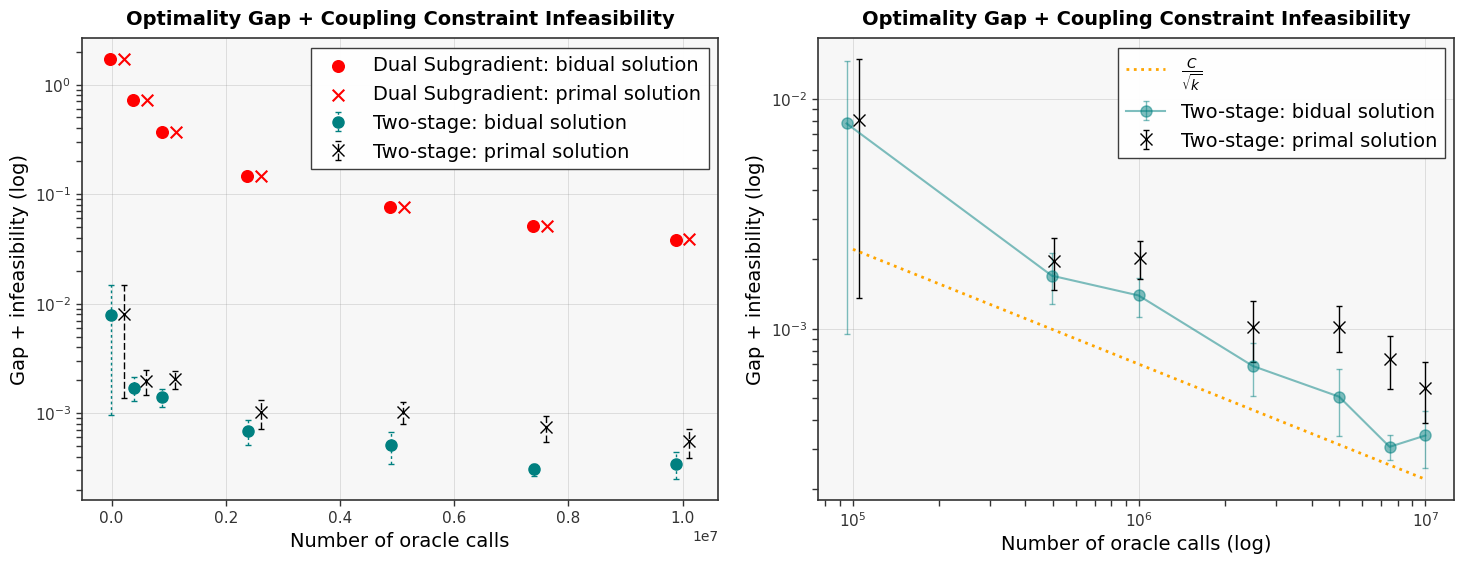

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax1.set_axisbelow(True)
ax1.yaxis.grid(color='gray', linewidth=0.3)
ax1.xaxis.grid(color='gray', linewidth=0.3)
ax2.set_axisbelow(True)
ax2.yaxis.grid(color='gray', linewidth=0.3)
ax2.xaxis.grid(color='gray', linewidth=0.3)

markersize = 8
s=70

# Apply style improvements to all subplots
for ax in [ax1, ax2]:
    # Light gray background
    ax.set_facecolor('#f7f7f7')
    
    # Grid lines (light gray, behind plot elements)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.3)
    #ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.3)
    
    # Set grid behind plot elements
    #ax.set_axisbelow(True)
    
    # Thicker axis spines with darker color
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('#333333')
    
    # Improve tick parameters
    ax.tick_params(which='both', direction='out', length=4, width=1, 
                   colors='#333333', labelsize=11)

offset = 110000


err1 = ax1.errorbar(np.array(max_number_oracle_calls_list)-offset, avg_cost_bidual_two_stage, std_cost_bidual_two_stage,
             fmt='o', 
             #marker='o',
             color="teal", label="Two-stage: bidual solution",
             capsize=2,          # Width of the caps
             markersize=markersize,
    elinewidth=1,       # Line width of error bars
    capthick=1,         # Thickness of the caps
    alpha=1.0          # Transparency of the error bars
            )


err2 = ax1.errorbar(np.array(max_number_oracle_calls_list)+offset, avg_cost_primal_two_stage, std_cost_primal_two_stage,
             fmt='x', color="black", label="Two-stage: primal solution",  # Changed to square marker and darker blue
             capsize=2,          # Width of the caps
    elinewidth=1,       # Line width of error bars
    capthick=1,         # Thickness of the caps
    alpha=1.0 ,         # Slightly less transparent
    markersize=markersize
            )


offset = 120000
err3 = ax1.scatter(np.array(max_number_oracle_calls_list) - offset, 
                   infeasibility_bidual_dual_sub_list + np.maximum(np.array(cost_bidual_dual_sub_list)-d_star, 0),
                   marker='o', color="red", label="Dual Subgradient: bidual solution",
                   s=s)

err4 = ax1.scatter(np.array(max_number_oracle_calls_list) + offset, 
                   infeasibility_primal_dual_sub_list + np.maximum(np.array(cost_primal_dual_sub_list)-d_star, 0),
                  marker='x', color="red", label="Dual Subgradient: primal solution",
                  s=s)

#ax1.plot(K_range,  1500/np.sqrt(np.array(K_range) + 1), color="red", label=r"$\frac{C}{\sqrt{K}}$")
ax1.set_xlabel("Number of oracle calls", fontsize=12)
ax1.set_ylabel("Gap + infeasibility (log)", fontsize=12)
ax1.legend(bbox_to_anchor=(0.5, 0.95),
               borderaxespad=0.1, fontsize=13)
ax1.set_title('Optimality Gap + Coupling Constraint Infeasibility')
#ax1.set_xscale("log")
ax1.set_yscale("log")

for bar in err1[2]:  # err[2] contains the Line2D objects for the error bars
    bar.set_linestyle((0, (2, 2)))  # Dotted line
for bar in err2[2]:  # err[2] contains the Line2D objects for the error bars
    bar.set_linestyle((0, (5, 2)))  # Dashed line (longer dashes)


offset = 5000

err1 = ax2.errorbar(np.array(max_number_oracle_calls_list) - offset, avg_cost_bidual_two_stage, std_cost_bidual_two_stage,
             marker='o', color="teal", label="Two-stage: bidual solution",
             capsize=2,          # Width of the caps
    elinewidth=1,       # Line width of error bars
    capthick=1,         # Thickness of the caps
    alpha=0.5,
               markersize=markersize           
            )


err2 = ax2.errorbar(np.array(max_number_oracle_calls_list) + offset, avg_cost_primal_two_stage, std_cost_primal_two_stage,
             fmt='x', color="black", label="Two-stage: primal solution",  # Changed to square marker and darker blue
             capsize=2,          # Width of the caps
    elinewidth=1,       # Line width of error bars
    capthick=1,         # Thickness of the caps
    alpha=1 ,      # Slightly less transparent,
    markersize=markersize
            )

inverse_sqrt_curve = np.array([0.7/np.sqrt(g) for g in max_number_oracle_calls_list])
ax2.plot(np.array(max_number_oracle_calls_list), 
         inverse_sqrt_curve, 
         color='orange',
         alpha=1.0, linewidth=2, linestyle=':',
         label=r'$\frac{C}{\sqrt{k}}$')

#ax1.plot(K_range,  1500/np.sqrt(np.array(K_range) + 1), color="red", label=r"$\frac{C}{\sqrt{K}}$")
ax2.set_xlabel("Number of oracle calls (log)", fontsize=12)
ax2.set_ylabel("Gap + infeasibility (log)", fontsize=12)
ax2.legend(bbox_to_anchor=(0.5, 0.95),
               borderaxespad=0.1, fontsize=13)

ax2.set_title('Optimality Gap + Coupling Constraint Infeasibility')
ax2.set_xscale("log")
ax2.set_yscale("log")


for ax in [ax1, ax2]:
    # Improve legend
    legend = ax.legend(framealpha=0.95, edgecolor='#333333', 
                      fancybox=False, shadow=False, fontsize=14)
    legend.get_frame().set_linewidth(1.0)
    
    # Larger, bolder labels
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, fontweight='medium')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, fontweight='medium')
    ax.set_title(ax.get_title(), fontsize=14, fontweight='bold', pad=10)

# Tighter layout
plt.tight_layout(pad=2.0)
#plt.savefig('figures/noncvx_convergence.pdf', bbox_inches='tight')